# Bid-shape EDA — how do Big-4 bids change structure across the reform sequence?

After nb08's identification work hit placebo failures (§9, §10), we pivot to a deeper descriptive pass on the **form** of bids. Most of the rich bid-level data has been touched only summarily: we have 172M DA offer-detail tranches, 313M IDA tranches, and 163M XBID orders with timestamps, all under-used.

This notebook looks for **bid-structure** patterns across the reform sequence: how many tranches firms use, how granular they are, how they compose offers. Unlike the quantity-level analysis in nb03–nb08, bid structure is a direct behavioural margin — it reflects what firms choose to submit, not what gets cleared.

**No identification claims here.** This is descriptive; findings motivate the separate question of whether to upgrade them causally later.


## § 0 — Setup

In [1]:
import warnings
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mtu.notebook_utils import (
    PROJECT_ROOT,
    IDA_REFORM, ISP15_REFORM, INTRADAY_REFORM, DAY_AHEAD_REFORM,
)

warnings.filterwarnings('ignore', category=RuntimeWarning)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

DET  = PROJECT_ROOT / 'data/processed/omie/mercado_diario/ofertas/det_all.parquet'
CAB  = PROJECT_ROOT / 'data/processed/omie/mercado_diario/ofertas/cab_all.parquet'
PANEL = PROJECT_ROOT / 'data/derived/reform_panel.parquet'

con = duckdb.connect()
con.execute("SET memory_limit='6GB'")
con.execute('SET threads=4')

DISP_TECHS = ('Ciclo Combinado', 'Nuclear',
              'Hidráulica Generación', 'Hidráulica de Bombeo Puro')

def _count(path):
    return con.execute('SELECT COUNT(*) FROM read_parquet(?)', [str(path)]).fetchone()[0]

print(f'DA cab rows:   {_count(CAB):>12,}')
print(f'DA det rows:   {_count(DET):>12,}')
print(f'panel rows:    {_count(PANEL):>12,}')
print(f'Reforms:  IDA={IDA_REFORM.date()}, ISP15={ISP15_REFORM.date()}, '
      f'MTU15-IDA={INTRADAY_REFORM.date()}, MTU15-DA={DAY_AHEAD_REFORM.date()}')

DA cab rows:      5,603,888
DA det rows:    172,453,443
panel rows:         148,298
Reforms:  IDA=2024-06-14, ISP15=2024-12-01, MTU15-IDA=2025-03-19, MTU15-DA=2025-10-01


## § 1 — How many price tranches do Big-4 firms use per DA offer-period?

A day-ahead offer consists of an **offer-period** (a specific trading period — one hour pre-MTU15-DA, one 15-min ISP post-MTU15-DA) for which the firm submits one or more **tranches** (a tranche = a price-quantity pair; several tranches form a step supply curve). Tranches-per-offer-period is the simplest measure of bid granularity: a firm using 1 tranche is offering its full capacity at a single price; a firm using 10 is offering a fine-grained step curve.

The first cut: tranches per DA sell-side offer-period, aggregated by regime × group × technology. If firms changed bid granularity across reforms, it should show here.


In [2]:
# §1 — Tranches per DA sell offer-period by regime × group × tech.
IDA = IDA_REFORM.date()
ISP = ISP15_REFORM.date()
IR  = INTRADAY_REFORM.date()
DR  = DAY_AHEAD_REFORM.date()

q1 = (
    "WITH "
    "panel_big AS (SELECT DISTINCT unit_code, CAST(date AS DATE) AS date, technology, big4 "
    f"              FROM read_parquet('{PANEL}') WHERE technology IN {DISP_TECHS}), "
    "cab_sell AS (SELECT CAST(date AS DATE) AS date, offer_code, version, unit_code "
    f"             FROM read_parquet('{CAB}') WHERE buy_sell='V'), "
    "tranches AS (SELECT CAST(date AS DATE) AS date, offer_code, version, period, "
    "                    COUNT(*) AS n_tranches "
    f"             FROM read_parquet('{DET}') GROUP BY 1,2,3,4) "
    "SELECT "
    f"  CASE WHEN t.date < DATE '{IDA}' THEN '1_6sess' "
    f"       WHEN t.date < DATE '{ISP}' THEN '2_3sess' "
    f"       WHEN t.date < DATE '{IR}'  THEN '3_ISP15' "
    f"       WHEN t.date < DATE '{DR}'  THEN '4_DA60_ID15' "
    "       ELSE '5_DA15_ID15' END AS regime, "
    "  CASE WHEN p.big4=1 THEN 'Big-4' ELSE 'Fringe' END AS group_label, "
    "  p.technology, "
    "  AVG(t.n_tranches) AS mean_tr, MEDIAN(t.n_tranches) AS med_tr, "
    "  COUNT(*) AS n_offer_periods, COUNT(DISTINCT c.unit_code) AS n_units "
    "FROM tranches t "
    "JOIN cab_sell c USING (date, offer_code, version) "
    "JOIN panel_big p ON p.unit_code = c.unit_code AND p.date = t.date "
    "GROUP BY 1,2,3 ORDER BY group_label, technology, regime"
)
s1 = con.execute(q1).fetchdf()

tech_order = ['Ciclo Combinado', 'Nuclear',
              'Hidráulica Generación', 'Hidráulica de Bombeo Puro']
regime_order = ['1_6sess', '2_3sess', '3_ISP15', '4_DA60_ID15', '5_DA15_ID15']

print('§1 · Tranches per DA sell offer-period, by regime × group × tech:')
print()
for grp in ['Big-4', 'Fringe']:
    print(f'=== {grp} ===')
    sub = s1[s1['group_label']==grp].copy()
    techs = [t for t in tech_order if t in sub['technology'].unique()]
    regs  = [r for r in regime_order if r in sub['regime'].unique()]
    piv = sub.pivot_table(index='technology', columns='regime',
                          values='med_tr', aggfunc='first').reindex(index=techs, columns=regs)
    piv_n = sub.pivot_table(index='technology', columns='regime',
                            values='n_offer_periods', aggfunc='first').reindex(index=techs, columns=regs)
    print('Median tranches per offer-period:')
    print(piv.round(1).fillna('—').to_string())
    print()
    print('Offer-periods sample size:')
    print(piv_n.fillna(0).astype(int).to_string())
    print()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

§1 · Tranches per DA sell offer-period, by regime × group × tech:

=== Big-4 ===
Median tranches per offer-period:
regime                     1_6sess  2_3sess  3_ISP15  4_DA60_ID15  5_DA15_ID15
technology                                                                    
Ciclo Combinado                7.0      4.0      4.0          2.0          2.0
Nuclear                        1.0      1.0      1.0          1.0          1.0
Hidráulica Generación          2.0      3.0      3.0          3.0          3.0
Hidráulica de Bombeo Puro      2.0      2.0      2.0          2.0          3.0

Offer-periods sample size:
regime                     1_6sess  2_3sess  3_ISP15  4_DA60_ID15  5_DA15_ID15
technology                                                                    
Ciclo Combinado               8162    26045    19399        15739        39140
Nuclear                      25490    22929    14738        25232        51733
Hidráulica Generación        60511    41145    29707        64859  

**Reading the regime × tech × group table.**

- **Big-4 CCGT** shows a clear decline in median tranches per offer across the reform sequence: $7 \to 4 \to 4 \to 2 \to 2$. From the 6-sess regime's step curves with ~7 price levels to the MTU15-DA world with 2-tranche offers — a roughly $3\times$ simplification in bid granularity.
- **Big-4 reservoir and pumped hydro** show the opposite pattern: tranches per offer *increase* across the reform sequence. Hydro offers become more granular.
- **Big-4 nuclear** is flat at 1 tranche throughout — consistent with baseload technology not needing price differentiation.
- **Fringe CCGT** is stable around 2 tranches throughout — much less granular than Big-4 historically. No similar reform-window simplification.
- **Fringe hydro** is essentially 1 tranche throughout.

The Big-4 CCGT simplification is the single biggest descriptive shift. The next cut is whether it's a step at a specific reform or a gradual drift.


## § 2 — Time-series of Big-4 median tranches by technology

The regime-level table in §1 averages across monthly variation. The monthly time series shows whether the CCGT decline is a gradual drift or a step at a specific reform date.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

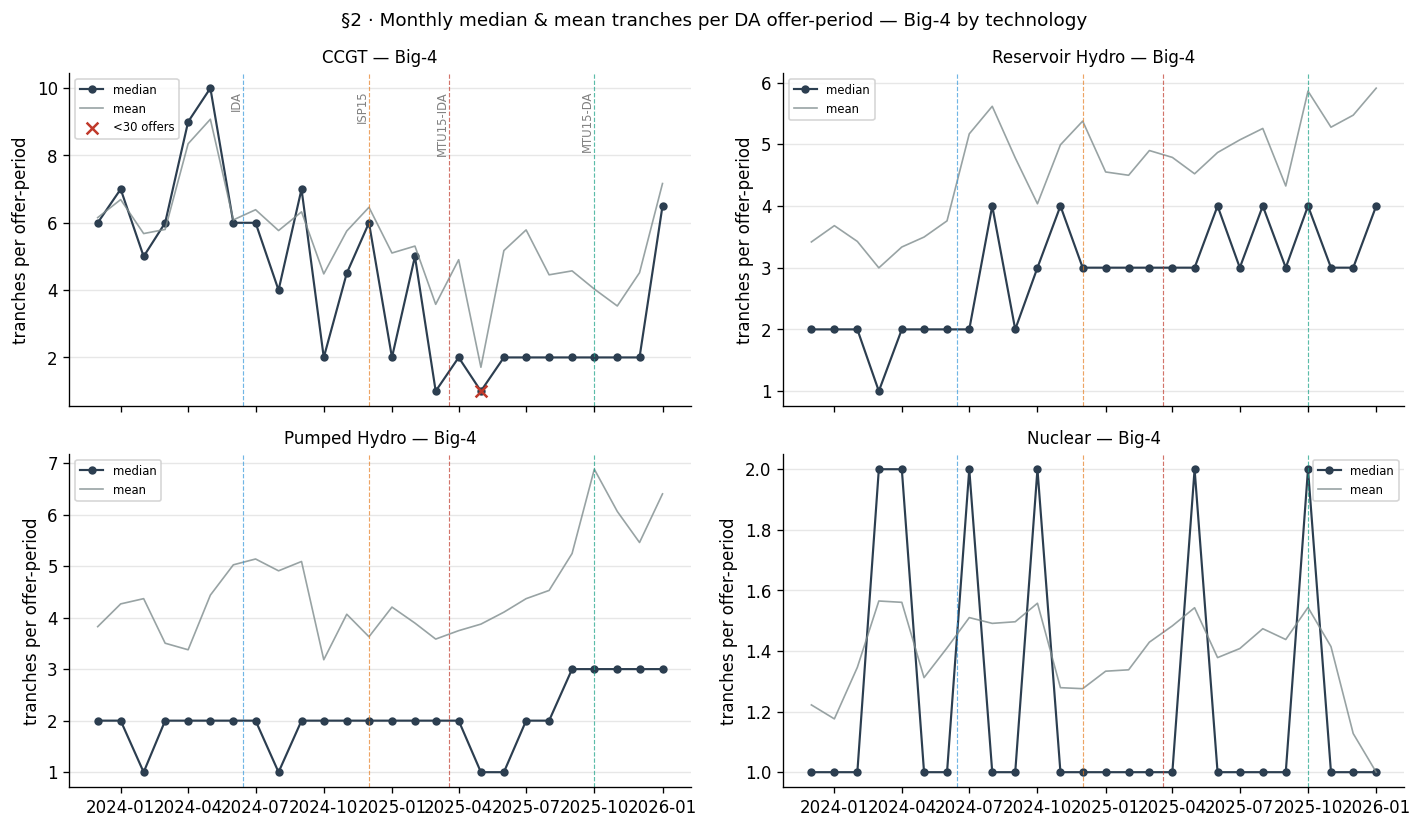

§2 · Monthly median tranches per offer-period (Big-4 by tech):
technology  Ciclo Combinado  Hidráulica Generación  Hidráulica de Bombeo Puro  Nuclear
mon                                                                                   
2023-12                 6.0                    2.0                        2.0      1.0
2024-01                 7.0                    2.0                        2.0      1.0
2024-02                 5.0                    2.0                        1.0      1.0
2024-03                 6.0                    1.0                        2.0      2.0
2024-04                 9.0                    2.0                        2.0      2.0
2024-05                10.0                    2.0                        2.0      1.0
2024-06                 6.0                    2.0                        2.0      1.0
2024-07                 6.0                    2.0                        2.0      2.0
2024-08                 4.0                    4.0                 

In [3]:
# §2 — Monthly median tranches per offer-period, Big-4 by tech, with sample size.
q2 = (
    "WITH "
    "panel_big AS (SELECT DISTINCT unit_code, CAST(date AS DATE) AS date, technology "
    f"              FROM read_parquet('{PANEL}') WHERE big4=1 AND technology IN {DISP_TECHS}), "
    "cab_sell AS (SELECT CAST(date AS DATE) AS date, offer_code, version, unit_code "
    f"             FROM read_parquet('{CAB}') WHERE buy_sell='V'), "
    "tranches AS (SELECT CAST(date AS DATE) AS date, offer_code, version, period, "
    "                    COUNT(*) AS n_tranches "
    f"             FROM read_parquet('{DET}') GROUP BY 1,2,3,4) "
    "SELECT DATE_TRUNC('month', t.date) AS mon, p.technology, "
    "       AVG(t.n_tranches) AS mean_tr, MEDIAN(t.n_tranches) AS med_tr, "
    "       COUNT(*) AS n_op, COUNT(DISTINCT c.unit_code) AS n_units "
    "FROM tranches t "
    "JOIN cab_sell c USING (date, offer_code, version) "
    "JOIN panel_big p ON p.unit_code=c.unit_code AND p.date=t.date "
    "GROUP BY 1,2 ORDER BY 2,1"
)
s2 = con.execute(q2).fetchdf()
s2['mon'] = pd.to_datetime(s2['mon'])

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
tech_plot = ['Ciclo Combinado', 'Hidráulica Generación',
             'Hidráulica de Bombeo Puro', 'Nuclear']
tech_labels = {'Ciclo Combinado': 'CCGT',
               'Hidráulica Generación': 'Reservoir Hydro',
               'Hidráulica de Bombeo Puro': 'Pumped Hydro',
               'Nuclear': 'Nuclear'}
MIN_SAMPLE = 30

for ax, tech in zip(axes.flat, tech_plot):
    sub = s2[s2['technology'] == tech].sort_values('mon')
    lo = sub['n_op'] < MIN_SAMPLE
    ax.plot(sub['mon'], sub['med_tr'], '-o', color='#2c3e50',
            markersize=4, lw=1.3, label='median')
    ax.plot(sub['mon'], sub['mean_tr'], '-', color='#7f8c8d', lw=1.0, alpha=0.8,
            label='mean')
    if lo.any():
        ax.scatter(sub.loc[lo, 'mon'], sub.loc[lo, 'med_tr'], marker='x', s=50,
                   color='#c0392b', zorder=5, label=f'<{MIN_SAMPLE} offers')
    for d, col in [(IDA_REFORM, '#3498db'), (ISP15_REFORM, '#e67e22'),
                   (INTRADAY_REFORM, '#c0392b'), (DAY_AHEAD_REFORM, '#16a085')]:
        ax.axvline(d, color=col, ls='--', lw=0.7, alpha=0.7)
    ax.set_title(f'{tech_labels[tech]} — Big-4', fontsize=10)
    ax.set_ylabel('tranches per offer-period')
    ax.grid(axis='y', alpha=0.3)
    ax.legend(loc='best', fontsize=7)

for d, lbl in [(IDA_REFORM, 'IDA'), (ISP15_REFORM, 'ISP15'),
               (INTRADAY_REFORM, 'MTU15-IDA'), (DAY_AHEAD_REFORM, 'MTU15-DA')]:
    axes[0, 0].text(d, axes[0, 0].get_ylim()[1]*0.95, lbl, rotation=90,
                    va='top', ha='right', fontsize=7, color='grey')

fig.suptitle('§2 · Monthly median & mean tranches per DA offer-period — Big-4 by technology',
             fontsize=11)
plt.tight_layout()
plt.show()

print('§2 · Monthly median tranches per offer-period (Big-4 by tech):')
piv_m = s2.pivot_table(index='mon', columns='technology', values='med_tr').round(1)
piv_m.index = piv_m.index.strftime('%Y-%m')
print(piv_m.fillna('—').to_string())
print()
print('§2 · Sample size — offer-periods per month:')
piv_n = s2.pivot_table(index='mon', columns='technology', values='n_op')
piv_n.index = piv_n.index.strftime('%Y-%m')
print(piv_n.fillna(0).astype(int).to_string())

**Reading the time series — the CCGT simplification is a STEP at MTU15-IDA, not a gradual drift.**

Big-4 CCGT tranches per offer-period, by month:

- **2023-12 to 2024-02:** stable around 5-7.
- **2024-03 to 2024-05:** brief spike to 9-10 (sample caveat: April-May 2024 have very few offers).
- **2024-06 (IDA) to 2025-02 (pre-MTU15-IDA):** 4-6 tranches median. No visible change at IDA or ISP15 boundaries.
- **2025-03 (MTU15-IDA, 2025-03-19):** median drops to **1**.
- **2025-04 onward:** stays at 1-2 tranches through the rest of the sample.

Even accounting for small-sample months (Apr-May 2025 have very few CCGT offers), the shift is sharp. March 2025 has 106 offer-periods (adequate sample) and median = 1. June-Dec 2025 all have 100+ offers with median ≤ 2.

**Reservoir hydro** shows the opposite: median tranches rise from ~2 pre-reform to ~3-4 post-MTU15-IDA. More granular, not less.

**Pumped hydro** is relatively stable but edges up after MTU15-DA (October 2025).

**Nuclear** is flat at 1 tranche, as expected.

**What this suggests (hypothesis, not identified claim).** Big-4 CCGT appears to have dramatically simplified its DA bid structure at MTU15-IDA, even though MTU15-IDA changed the *intraday* market, not the DA market. A natural reading: once 15-min intraday trading tools became available (2025-03-19), CCGT firms shifted their strategic granularity from DA to IDA. DA offers become "commitment" bids at one or two prices; the fine-grained price-quantity response happens in the 15-min intraday market. Hydro and pumped hydro do the opposite, possibly because water-management opportunity-cost bidding benefits from finer DA granularity to signal scheduling intent.

**Caveats for this descriptive finding.**
1. Sample composition: Spring 2025 has very few active CCGT offers (April 2025: 28 offers; May 2025: 1 offer). Read with caution.
2. Unit composition: if the CCGT units that remain active post-MTU15-IDA are a non-random subset, the change may reflect who is submitting rather than how.
3. "Tranches per offer" is a coarse metric — it treats a 2-tranche offer with prices (30, 300) the same as (30, 35). Richer bid-shape metrics (price range, step height distribution) come next.

This is the first non-trivial bid-structure pattern this project has found. Whether it reflects strategic repositioning or reporting-protocol changes is the next question.
